In this code we will try to fit a polynomial function to given data. 

Epoch [1000/10000], Loss: 0.0007
Epoch [2000/10000], Loss: 0.0002
Epoch [3000/10000], Loss: 0.0001
Epoch [4000/10000], Loss: 0.0001
Epoch [5000/10000], Loss: 0.0001
Epoch [6000/10000], Loss: 0.0001
Epoch [7000/10000], Loss: 0.0001
Epoch [8000/10000], Loss: 0.0001
Epoch [9000/10000], Loss: 0.0001
Epoch [10000/10000], Loss: 0.0001


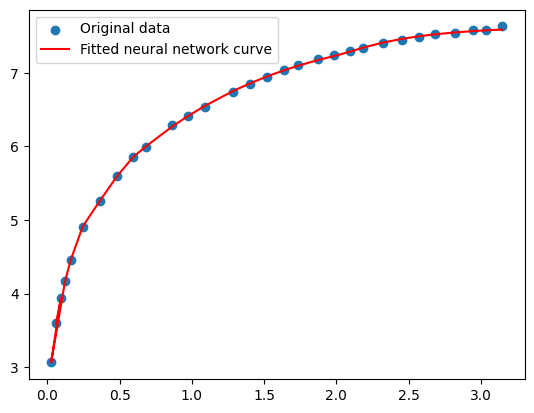

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from schsolve import neural_trainer 

# Given data
x_arr = [0.05847605202762446, 0.09368133926144129, 0.02553674111901877, 0.12202160567522635, 0.16003611609405566, 0.24413213708770543, 0.3608541207127307, 0.4828156660963421, 0.5925537648106403, 0.6828254544699208, 0.8650083393362422, 0.9700092097167208, 1.0899796914958313, 1.2832984815261785, 1.3989175729994532, 1.5187260724968614, 1.6395984551609901, 1.7358666172693598, 1.8735801205673441, 1.9866724565710312, 2.09323202133587, 2.183381753405148, 2.3227001711518453, 2.453807876555414, 2.5711061215651685, 2.6829292712776533, 2.823922793003788, 2.9481701092904693, 3.038817560173, 3.146991745070998]
y_arr = np.array([3.5941027524177587, 3.938737981277658, 3.0640654170130324, 4.168456623425607, 4.45059841976562, 4.910650536663227, 5.254585868573394, 5.596251576465882, 5.853283139036311, 5.99639367713345, 6.283705918720844, 6.414477894295825, 6.538290393011855, 6.743657312659085, 6.849114251113775, 6.935138852908203, 7.030197134928828, 7.0991086362566005, 7.186596171618144, 7.233695935987047, 7.297650376324034, 7.3382753032677375, 7.397785785092296, 7.440760914421173, 7.482294746164857, 7.524834368602767, 7.536685144221717, 7.583423794921136, 7.583418199201171, 7.62755164256274])

# Convert data to tensors
x = torch.tensor(x_arr, dtype=torch.float32).view(-1, 1)
y = torch.tensor(y_arr, dtype=torch.float32).view(-1, 1)

# Get the maximum value of the y-axis data
y_max = max(y_arr)

# Initialize the model
#model = DeepNN()
model = neural_trainer(input_dim = 1, output_dim = 1, nl = 2, nu = 22, beta = 1.08)
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# Train the model
num_epochs = 10000 #0000
for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(x)*y_max
    loss = criterion(y_pred, y)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print the loss every 100 epochs
    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Plot the results
plt.scatter(x_arr, y_arr, label='Original data')
plt.plot(x_arr, y_pred.detach().numpy(), label='Fitted neural network curve', color='red')
plt.legend()
plt.show()

# sqrt(x)

In [116]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define a simple sine function to fit
def sine_function(x):
    return np.sin(x)

# Generate synthetic data
x_data_sine = np.linspace(0, 2 * np.pi, 100)
y_data_sine = sine_function(x_data_sine) + np.random.normal(0, 0.1, size=len(x_data_sine))

# Convert data to PyTorch tensors
x_tensor_sine = torch.tensor(x_data_sine, dtype=torch.float32).unsqueeze(1)
y_tensor_sine = torch.tensor(y_data_sine, dtype=torch.float32).unsqueeze(1)

# Define a simple neural network with one hidden layer (same architecture as before)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1, 10)
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the neural network
net_sine = Net()

# Define the L-BFGS optimizer
optimizer_sine = optim.LBFGS(net_sine.parameters(), lr=0.01)

# Training loop
def closure_sine():
    optimizer_sine.zero_grad()
    y_pred_sine = net_sine(x_tensor_sine)
    loss_sine = criterion(y_pred_sine, y_tensor_sine)
    loss_sine.backward()
    return loss_sine

for _ in range(1000):
    optimizer_sine.step(closure_sine)

# Generate predictions using the trained model
with torch.no_grad():
    y_pred_sine = net_sine(x_tensor_sine)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(x_data_sine, y_data_sine, label="Data")
plt.scatter(x_data_sine, y_pred_sine.numpy(), color='r', label="Fitted Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting a Sine Function using L-BFGS")
plt.legend()
plt.show()


TypeError: LBFGS.__init__() got an unexpected keyword argument 'weight_decay'

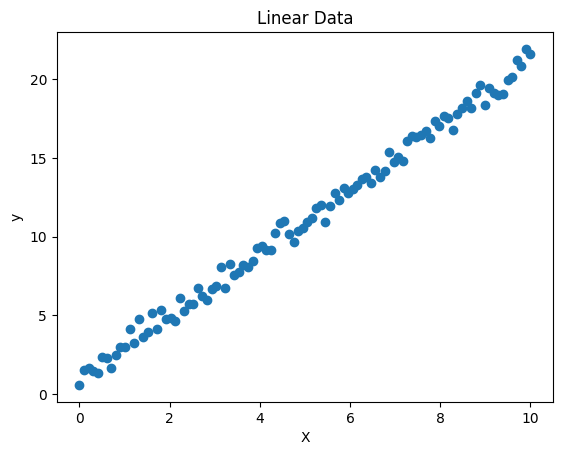

In [117]:
import torch
import matplotlib.pyplot as plt

# Generate linear data
def generate_linear_data(num_samples=100):
    X = torch.linspace(0, 10, num_samples).view(-1, 1)
    y = 2 * X + 1 + torch.randn(num_samples, 1) * 0.5
    return X, y

X, y = generate_linear_data()

# Plot the data
plt.scatter(X, y, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Data")
plt.show()


In [118]:
import torch.nn as nn

class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(1, 1)  # One input feature, one output neuron

    def forward(self, x):
        return self.linear(x)

model = LinearModel()


In [3]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

num_epochs = 1000
for epoch in range(num_epochs):
    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

plt.scatter(X, y, label="Data")
plt.plot(X, model(X).detach().numpy(), color='red', label="Fitted Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression with PyTorch")
plt.legend()
plt.show()

NameError: name 'model' is not defined